In [4]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt


# Change this to your actual file path
path = Path("Yb160_K0/QFAM_output/check_strength.out")

# Regex for lines like:
# 0.100000000E+01  0.181735190E-01  -0.287802597E+01 + -0.570937937E-01 i  0.931E-06
float_pat = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[EDed][+-]?\d+)?"

pattern = re.compile(
    rf"""
    ^\s*
    (?P<omega>{float_pat})\s+
    (?P<strength>{float_pat})\s+
    (?P<reS>{float_pat})\s+
    (?P<sign>[+-])\s*
    (?P<imS>{float_pat})\s+i\s+
    (?P<residual>{float_pat})
    """,
    re.VERBOSE,
)

rows = []

with open(path, "r") as f:
    for line in f:
        match = pattern.match(line)
        if match:
            d = match.groupdict()

            def to_float(x):
                return float(x.replace("D", "E").replace("d", "E"))

            omega = to_float(d["omega"])
            strength = to_float(d["strength"])
            reS = to_float(d["reS"])
            imS = to_float(d["imS"])
            residual = to_float(d["residual"])

            # The imaginary part appears after an explicit + or -
            if d["sign"] == "-":
                imS *= -1

            rows.append(
                {
                    "omega_MeV": omega,
                    "strength": strength,
                    "Re_S": reS,
                    "Im_S": imS,
                    "residual_error": residual,
                }
            )

df = pd.DataFrame(rows)

df.head()

,omega_MeV,strength,Re_S,Im_S,residual_error
0,0.0,-6.372443e-17,-2.887632,2.001962e-16,4.130000e-07
1,0.1,2.725547e-03,-2.887205,-8.562558e-03,3.950000e-07
2,0.2,5.321746e-03,-2.886065,-1.671876e-02,9.750000e-07
3,0.3,7.721420e-03,-2.884469,-2.425756e-02,8.330000e-07
4,0.4,9.894174e-03,-2.882638,-3.108346e-02,7.010000e-07


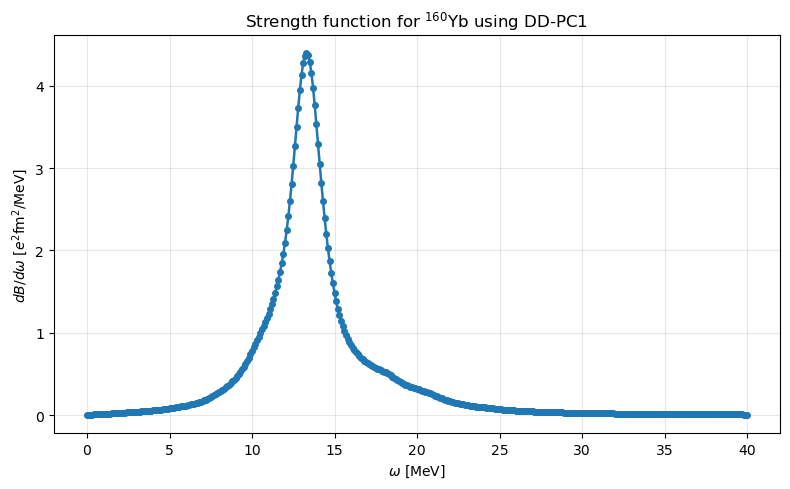

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    df["omega_MeV"],
    df["strength"],
    marker="o",
    linewidth=1.8,
    markersize=4,
)

plt.xlabel(r"$\omega$ [MeV]")
plt.ylabel(r"$dB/d\omega$ [$e^2 \mathrm{fm}^2 / \mathrm{MeV}$]")
plt.title(r"Strength function for $^{160}$Yb using DD-PC1")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

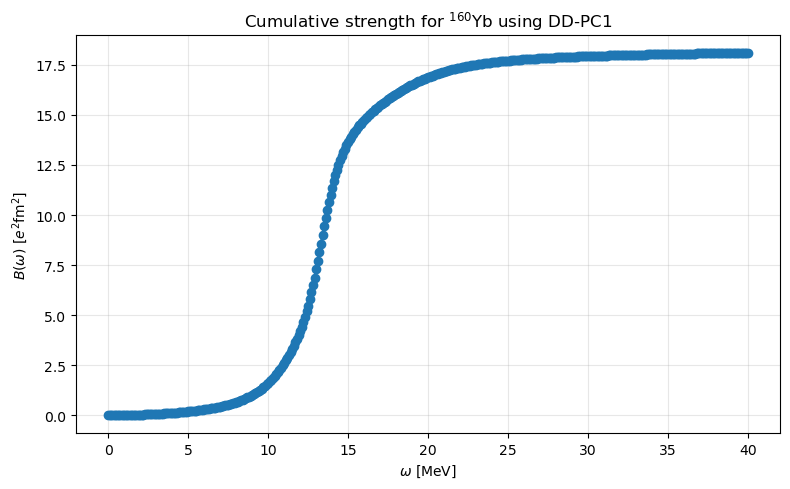

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Integrated cumulative strength B(omega)
omega = df["omega_MeV"].to_numpy()
dBdw = df["strength"].to_numpy()

B = np.zeros_like(dBdw)
B[1:] = np.cumsum(0.5 * (dBdw[1:] + dBdw[:-1]) * np.diff(omega))

df["B_cumulative"] = B

plt.figure(figsize=(8, 5))
plt.plot(df["omega_MeV"], df["B_cumulative"], marker="o", linewidth=1.8)

plt.xlabel(r"$\omega$ [MeV]")
plt.ylabel(r"$B(\omega)$ [$e^2 \mathrm{fm}^2$]")
plt.title(r"Cumulative strength for $^{160}$Yb using DD-PC1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()